# HOUSE PRICE PREDICTION USING LINEAR REGRESSION

## Objective

To predict house prices using living area, number of bedrooms, full bathrooms, and half bathrooms.

## Algorithm Used

Linear Regression

# 1. Dataset Loading

The dataset used in this project is the Kaggle House Prices dataset.

The training dataset contains house-related information and the
target variable is SalePrice.

The dataset contains 1460 rows and 81 columns.

In [6]:
import pandas as pd

df = pd.read_csv("/train.csv")

print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

# 2. Feature Selection

We selected four features for predicting house prices:

- GrLivArea — Above-ground living area
- BedroomAbvGr — Number of bedrooms
- FullBath — Number of full bathrooms
- HalfBath — Number of half bathrooms

Target variable:
SalePrice — House sale price

In [7]:
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'HalfBath']]
y = df['SalePrice']

print(X.head())
print(y.head())

   GrLivArea  BedroomAbvGr  FullBath  HalfBath
0       1710             3         2         1
1       1262             3         2         0
2       1786             3         2         1
3       1717             3         1         0
4       2198             4         2         1
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


# 3. Train-Test Split

The dataset is divided into two parts:
- 80% data is used for training the model.
- 20% data is used for testing the model.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 4)
Testing data: (292, 4)


# 4. Train the Linear Regression Model

A Linear Regression model is trained using the training data.
The model learns the relationship between the selected features
and the house sale price.

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


# 5. Make Predictions

The trained Linear Regression model is used to predict house
prices for the test data.

In [10]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[112217.01764971 305769.10684585 134851.72968815 203697.6554177
 225925.43719242 121066.18312231 206963.72433062 187148.93496707
 121066.18312231 149891.75484177]


# 6. Actual vs Predicted Prices

The actual house prices are compared with the prices predicted
by the Linear Regression model.

In [11]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print(comparison.head(10))

   Actual Price  Predicted Price
0        154500    112217.017650
1        325000    305769.106846
2        115000    134851.729688
3        159000    203697.655418
4        315500    225925.437192
5         75500    121066.183122
6        311500    206963.724331
7        146000    187148.934967
8         84500    121066.183122
9        135500    149891.754842


# 7. Model Evaluation

The model is evaluated using three metrics:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score (Coefficient of Determination)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 36018.563138363446
RMSE: 53018.32669198515
R2 Score: 0.6335301929422245


# 8. Predict Price for a New House

The trained model is used to predict the price of a new house
based on its living area, bedrooms, and bathrooms.

In [13]:
new_house = pd.DataFrame({
    'GrLivArea': [2000],
    'BedroomAbvGr': [3],
    'FullBath': [2],
    'HalfBath': [1]
})

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 242491.45083504182


# 9. Actual vs Predicted Graph

The scatter plot shows the relationship between actual house
prices and the prices predicted by the Linear Regression model.

Points closer to the expected relationship indicate smaller
prediction errors.

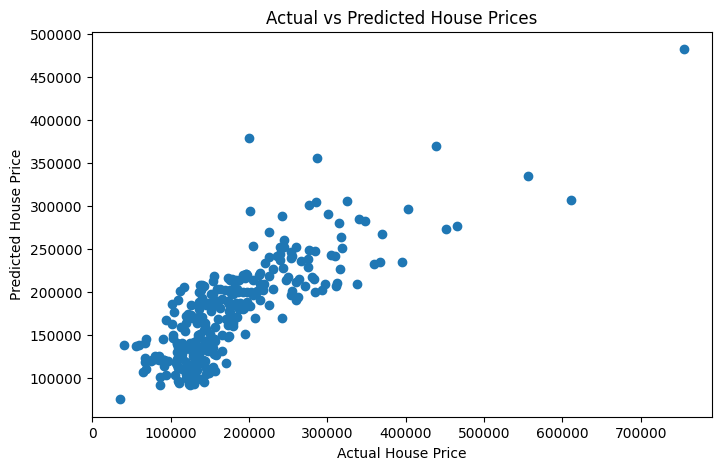

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

# 10. Save the Trained Model

The trained Linear Regression model is saved as a file
so that it can be used again without retraining.

In [15]:
import joblib

joblib.dump(model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# 11. Predict Price for a New House

The trained model is used to predict the price of a new house
based on its living area, bedrooms, and bathrooms.

# 12. Conclusion

In this project, a Linear Regression model was developed to
predict house prices.

Four features were used:
- GrLivArea
- BedroomAbvGr
- FullBath
- HalfBath

The dataset was divided into training and testing data.
The model was trained using the training data and evaluated
using MAE, RMSE, and R² Score.

The model achieved an R² Score of 0.6335.

Finally, the model predicted the price of a new house with
2000 sq ft living area, 3 bedrooms, 2 full bathrooms and
1 half bathroom as approximately $242,491.45.

This project demonstrates how machine learning can be used
to predict house prices.